# 02 — Analyze

**Takes in:** `data/analysis_sample.csv` (written by [`01_merge.ipynb`](01_merge.ipynb))

**Does:** describes the analysis sample, then fits an OLS model of tract upward mobility on neighborhood characteristics among rural tracts, with a logistic model of the above-median indicator as a robustness check. Predictors are standardized so the coefficients are comparable across variables measured in different units.

**Outputs:** `output/fig1_mobility_by_density.png`, `output/fig2_rural_ols_coefficients.png`, `output/table1_analysis_sample.tex`, `output/table3_ols_results.tex`


In [1]:
import os
import sys

import numpy as np
import pandas as pd
import statsmodels.api as sm
import matplotlib
import matplotlib.pyplot as plt

sys.path.insert(0, os.path.abspath("."))
import utils

df = pd.read_csv(utils.data_path("analysis_sample.csv"))
print("loaded analysis sample: {:,} tracts".format(len(df)))

loaded analysis sample: 71,958 tracts


## Functions

In [2]:
def style_axes(ax):
    """Recessive grid and axes; no top/right spines."""
    ax.set_axisbelow(True)
    for side in ["top", "right"]:
        ax.spines[side].set_visible(False)
    for side in ["left", "bottom"]:
        ax.spines[side].set_color(utils.GRID)
    ax.tick_params(colors=utils.INK_MUTED, length=0)


def fit_ols(df, outcome, predictors):
    """OLS of `outcome` on standardized `predictors`, on complete cases.

    Predictors are z-scored so a coefficient reads as "change in the outcome
    per one-SD increase in that characteristic" and is comparable across
    variables measured in different units. The outcome is left in its native
    units (an income rank between 0 and 1).
    """
    cols = list(predictors) + [outcome]
    n_start = len(df)
    complete = df[cols].dropna()
    print("complete cases: {:,} of {:,} ({:,} dropped for missingness)".format(
        len(complete), n_start, n_start - len(complete)))

    X = (complete[predictors] - complete[predictors].mean()) / complete[predictors].std()
    X = sm.add_constant(X)
    model = sm.OLS(complete[outcome], X).fit()
    print("R-squared: {:.3f}".format(model.rsquared))
    return model


def fit_logit(df, outcome, predictors):
    """Logistic regression of a binary `outcome` on the same standardized predictors."""
    cols = list(predictors) + [outcome]
    complete = df[cols].dropna()
    X = (complete[predictors] - complete[predictors].mean()) / complete[predictors].std()
    X = sm.add_constant(X)
    model = sm.Logit(complete[outcome].astype(int), X).fit(disp=0)
    print("pseudo R-squared: {:.3f}".format(model.prsquared))
    return model


def coef_frame(model, labels):
    """Tidy coefficients with 95% confidence intervals, excluding the intercept."""
    ci = model.conf_int()
    out = pd.DataFrame({
        "term": model.params.index,
        "beta": model.params.values,
        "lo": ci[0].values,
        "hi": ci[1].values,
        "pval": model.pvalues.values,
    })
    out = out[out["term"] != "const"].copy()
    out["label"] = out["term"].map(labels)
    return out.sort_values("beta")

## Figure 1 — mobility across density categories

Motivation for the question: rural tracts are not uniformly low-opportunity. The spread *within* the rural category is wider than the gap between categories.


wrote /Users/maxfortner/Documents/Dartmouth/QSS20/qss20-rural-mobility/output/fig1_mobility_by_density.png


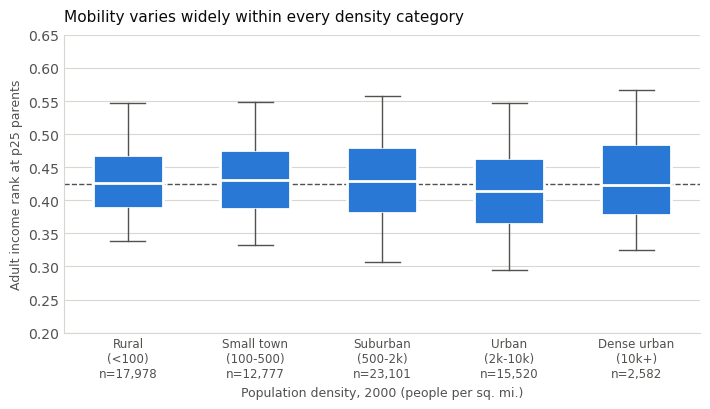

In [3]:
def fig1_mobility_by_density(df, out_path):
    order = [c for c in utils.DENSITY_LABELS if c in set(df["density_cat"].dropna())]
    groups = [df.loc[df["density_cat"] == c, utils.MOBILITY_VAR].dropna().values
              for c in order]

    fig, ax = plt.subplots(figsize=(7.2, 4.2))
    ## whis=(5, 95) gives whiskers that are describable percentiles rather than
    ## the default 1.5*IQR rule
    bp = ax.boxplot(groups, patch_artist=True, widths=0.55, showfliers=False,
                    whis=(5, 95), medianprops=dict(color="white", linewidth=2))
    for patch in bp["boxes"]:
        patch.set_facecolor(utils.BLUE)
        patch.set_edgecolor("white")
        patch.set_linewidth(2)
    for element in ["whiskers", "caps"]:
        for line in bp[element]:
            line.set_color(utils.INK_MUTED)
            line.set_linewidth(1)

    ax.axhline(df[utils.MOBILITY_VAR].median(), color=utils.INK_MUTED,
               linestyle="--", linewidth=1, zorder=0)

    ax.set_xticks(range(1, len(order) + 1))
    ax.set_xticklabels(["{}\nn={:,}".format(c, len(g)) for c, g in zip(order, groups)],
                       fontsize=8.5, color=utils.INK_MUTED)
    ax.set_ylabel("Adult income rank at p25 parents", fontsize=9, color=utils.INK_MUTED)
    ax.set_xlabel("Population density, 2000 (people per sq. mi.)",
                  fontsize=9, color=utils.INK_MUTED)
    ax.set_title("Mobility varies widely within every density category",
                 fontsize=11, color=utils.INK, loc="left", pad=10)
    ax.set_ylim(0.20, 0.65)
    ax.yaxis.grid(True, color=utils.GRID, linewidth=0.8)
    style_axes(ax)

    fig.tight_layout()
    fig.savefig(out_path, dpi=200, facecolor="white")
    print("wrote", out_path)
    return fig


_ = fig1_mobility_by_density(df, utils.output_path("fig1_mobility_by_density.png"))

## Figure 2 — what predicts mobility among rural tracts

Fitted on rural tracts only (density under 100 people per square mile). The dashed line at zero is the null; a coefficient of $-0.02$ means a one-SD increase in that characteristic is associated with a two-point drop in the adult income rank.


In [4]:
rural = df[df["popdensity2000"] < utils.RURAL_CUTOFF].copy()
predictors = list(utils.COVARIATES.keys())

print("rural tracts: {:,}".format(len(rural)))
ols = fit_ols(rural, utils.MOBILITY_VAR, predictors)
ols.summary()

rural tracts: 17,978
complete cases: 17,310 of 17,978 (668 dropped for missingness)
R-squared: 0.349


<class 'statsmodels.iolib.summary.Summary'>
"""
                              OLS Regression Results                             
=================================================================================
Dep. Variable:     kfr_pooled_pooled_p25   R-squared:                       0.349
Model:                               OLS   Adj. R-squared:                  0.348
Method:                    Least Squares   F-statistic:                     926.3
Date:                   Tue, 18 Aug 2026   Prob (F-statistic):               0.00
Time:                           10:24:57   Log-Likelihood:                 27106.
No. Observations:                  17310   AIC:                        -5.419e+04
Df Residuals:                      17299   BIC:                        -5.410e+04
Df Model:                             10                                         
Covariance Type:               nonrobust                                         
================================================================================================
                                   coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------------
const                            0.4320      0.000   1124.066      0.000       0.431       0.433
singleparent_share2000          -0.0271      0.001    -50.480      0.000      -0.028      -0.026
poor_share2000                   0.0024      0.001      3.529      0.000       0.001       0.004
mean_commutetime2000            -0.0109      0.000    -25.969      0.000      -0.012      -0.010
ann_avg_job_growth_2004_2013     0.0018      0.000      4.566      0.000       0.001       0.003
mail_return_rate2010             0.0008      0.000      1.673      0.094      -0.000       0.002
gsmn_math_g3_2013                0.0039      0.000      8.764      0.000       0.003       0.005
hhinc_mean2000                  -0.0064      0.001     -7.643      0.000      -0.008      -0.005
emp2000                          0.0037      0.001      7.274      0.000       0.003       0.005
frac_coll_plus2000               0.0109      0.001     16.326      0.000       0.010       0.012
share_white2000                  0.0077      0.001     14.253      0.000       0.007       0.009
==============================================================================
Omnibus:                     1322.564   Durbin-Watson:                   1.105
Prob(Omnibus):                  0.000   Jarque-Bera (JB):             3496.212
Skew:                           0.440   Prob(JB):                         0.00
Kurtosis:                       5.018   Cond. No.                         5.56
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

wrote /Users/maxfortner/Documents/Dartmouth/QSS20/qss20-rural-mobility/output/fig2_rural_ols_coefficients.png
n = 17,310, R-squared = 0.349


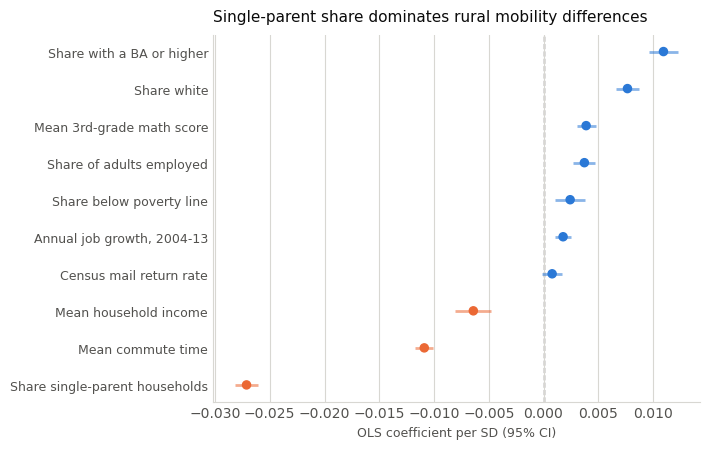

In [5]:
def fig2_ols_coefficients(coefs, out_path, n_obs, r2):
    fig, ax = plt.subplots(figsize=(7.2, 4.6))
    ypos = np.arange(len(coefs))
    colors = [utils.BLUE if b > 0 else utils.ORANGE for b in coefs["beta"]]

    ax.hlines(ypos, coefs["lo"], coefs["hi"], color=colors, linewidth=2, alpha=0.55)
    ax.scatter(coefs["beta"], ypos, color=colors, s=34, zorder=3)
    ax.axvline(0, color=utils.INK_MUTED, linestyle="--", linewidth=1, zorder=0)

    ax.set_yticks(ypos)
    ax.set_yticklabels(coefs["label"], fontsize=9, color=utils.INK)
    ax.set_xlabel("OLS coefficient per SD (95% CI)", fontsize=9, color=utils.INK_MUTED)
    ax.set_title("Single-parent share dominates rural mobility differences",
                 fontsize=11, color=utils.INK, loc="left", pad=10)
    ax.xaxis.grid(True, color=utils.GRID, linewidth=0.8)
    style_axes(ax)

    fig.tight_layout()
    fig.savefig(out_path, dpi=200, facecolor="white")
    print("wrote", out_path)
    print("n = {:,}, R-squared = {:.3f}".format(n_obs, r2))
    return fig


coefs = coef_frame(ols, utils.COVARIATES)
_ = fig2_ols_coefficients(coefs, utils.output_path("fig2_rural_ols_coefficients.png"),
                          int(ols.nobs), ols.rsquared)

## Robustness — logistic model of the above-median indicator

In [6]:
logit = fit_logit(rural, "above_median_mobility", predictors)
logit_coefs = coef_frame(logit, utils.COVARIATES)

comparison = (coefs[["label", "beta"]].rename(columns={"beta": "ols_beta"})
              .merge(logit_coefs[["label", "beta"]].rename(columns={"beta": "logit_beta"}),
                     on="label"))
comparison["same_sign"] = np.sign(comparison["ols_beta"]) == np.sign(comparison["logit_beta"])
comparison.sort_values("ols_beta")

pseudo R-squared: 0.187


,label,ols_beta,logit_beta,same_sign
0,Share single-parent households,-0.027119,-0.934161,True
1,Mean commute time,-0.010890,-0.316639,True
2,Mean household income,-0.006410,-0.200517,True
3,Census mail return rate,0.000784,-0.060257,False
4,"Annual job growth, 2004-13",0.001786,0.058651,True
5,Share below poverty line,0.002429,-0.094092,False
6,Share of adults employed,0.003729,0.061026,True
7,Mean 3rd-grade math score,0.003889,0.094535,True
8,Share white,0.007664,0.303143,True
9,Share with a BA or higher,0.010950,0.423845,True


## Tables

In [7]:
def table1_sample(df, out_path):
    """Sample characterization table."""
    rural = df[df["popdensity2000"] < utils.RURAL_CUTOFF]
    rows = [
        ("Census tracts in merged sample", "{:,}".format(len(df))),
        ("Rural tracts ($<${} people/sq.\\ mi.)".format(utils.RURAL_CUTOFF),
         "{:,}".format(len(rural))),
        ("Commuting zones represented", "{:,}".format(df["cz"].nunique())),
        ("Median tract mobility (income rank)",
         "{:.3f}".format(df[utils.MOBILITY_VAR].median())),
        ("Std.\\ dev.\\ of tract mobility",
         "{:.3f}".format(df[utils.MOBILITY_VAR].std())),
        ("Median children per tract estimate",
         "{:,.0f}".format(df[utils.COUNT_VAR].median())),
    ]
    lines = ["\\begin{tabular}{lr}", "\\toprule",
             "Analysis sample & Value \\\\", "\\midrule"]
    lines += ["{} & {} \\\\".format(k, v) for k, v in rows]
    lines += ["\\bottomrule", "\\end{tabular}"]
    with open(out_path, "w") as f:
        f.write("\n".join(lines) + "\n")
    print("wrote", out_path)


def table3_ols(coefs, model, out_path):
    """OLS coefficients, standard errors, and p-values as a LaTeX table."""
    lines = ["\\begin{tabular}{lrrr}", "\\toprule",
             "Characteristic (per SD) & $\\beta$ & 95\\% CI & $p$ \\\\", "\\midrule"]
    for _, r in coefs.sort_values("beta").iterrows():
        lines.append("{} & {:.4f} & [{:.4f}, {:.4f}] & {:.3f} \\\\".format(
            r["label"], r["beta"], r["lo"], r["hi"], r["pval"]))
    lines += ["\\midrule",
              "N & \\multicolumn{{3}}{{r}}{{{:,}}} \\\\".format(int(model.nobs)),
              "$R^2$ & \\multicolumn{{3}}{{r}}{{{:.3f}}} \\\\".format(model.rsquared),
              "\\bottomrule", "\\end{tabular}"]
    with open(out_path, "w") as f:
        f.write("\n".join(lines) + "\n")
    print("wrote", out_path)


table1_sample(df, utils.output_path("table1_analysis_sample.tex"))
table3_ols(coefs, ols, utils.output_path("table3_ols_results.tex"))

wrote /Users/maxfortner/Documents/Dartmouth/QSS20/qss20-rural-mobility/output/table1_analysis_sample.tex
wrote /Users/maxfortner/Documents/Dartmouth/QSS20/qss20-rural-mobility/output/table3_ols_results.tex


## Takeaway

Among rural tracts, the share of single-parent households is by far the strongest correlate of upward mobility (a one-SD increase is associated with a 2.7-point drop in adult income rank, roughly 2.5x the next-largest coefficient), and it holds the same sign and top rank in the logistic specification.

Two coefficients flip against their bivariate direction and should not be read at face value: the poverty share turns *positive* and mean household income turns *negative* once single-parent share is in the model. This is a collinearity artifact — these characteristics move together across tracts, so conditioning on one absorbs most of the shared variation and leaves the others fitting residual noise. The honest reading is that the model separates a single "family structure and disadvantage" dimension, not ten independent predictors, and the paper should say so rather than interpret each beta separately.

These are descriptive associations on cross-sectional tract data, not causal estimates: the covariates are measured contemporaneously with the childhood period rather than before it, and tracts with suppressed mobility estimates are systematically small.
